In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn import set_config
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

from sksurv.functions import StepFunction
from sksurv.linear_model import CoxnetSurvivalAnalysis, CoxPHSurvivalAnalysis
from sksurv.metrics import cumulative_dynamic_auc
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.util import Surv

## Prepare Datasets

In [2]:
# load pre-processed datasets
train_data    = pd.read_csv("../datasets/csv_files/ml_datasets/train_data.csv")
test_data_one   = pd.read_csv("../datasets/csv_files/ml_datasets/test_data_one.csv")
test_data_two   = pd.read_csv("../datasets/csv_files/ml_datasets/test_data_two.csv")
test_data_three = pd.read_csv("../datasets/csv_files/ml_datasets/test_data_three.csv")

In [3]:
# define X & y for all datasets
X_train = train_data.drop(columns=['sample_name', 'relapse_free_event', 'relapse_free_time'])
y_train = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', train_data)

X_test_one = test_data_one.drop(columns=['sample_name', 'relapse_free_event', 'relapse_free_time'])
X_test_one = X_test_one[X_train.columns]
y_test_one = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', test_data_one)

X_test_two = test_data_two.drop(columns=['sample_name', 'relapse_free_event', 'relapse_free_time'])
X_test_two = X_test_two[X_train.columns]
y_test_two = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', test_data_two)

X_test_three = test_data_three.drop(columns=['sample_name', 'relapse_free_event', 'relapse_free_time'])
X_test_three = X_test_three[X_train.columns]
y_test_three = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', test_data_three)

## Load Models & Compute Risk Scores

In [4]:
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.metrics import cumulative_dynamic_auc
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.exceptions import FitFailedWarning
import joblib, os, warnings

### Univariate Cox
Risk score = Σ(β_i × expr_i) using per-gene betas from univariate Cox regression.

In [5]:
# Load univariate Cox betas from pre-computed results
uni_results   = pd.read_csv("../datasets/csv_files/univariate_cox_sig_train.csv")
beta_series   = uni_results.set_index("gene")["beta"]
sig_genes_uni = beta_series.index.tolist()

def uni_cox_score(X):
    common = [g for g in beta_series.index if g in X.columns]
    return (X[common] @ beta_series[common]).values

uni_risk = {
    "train": uni_cox_score(X_train),
    "test1": uni_cox_score(X_test_one),
    "test2": uni_cox_score(X_test_two),
    "test3": uni_cox_score(X_test_three),
}
print(f"Univariate Cox: {len(sig_genes_uni)} significant genes used as risk predictors")

Univariate Cox: 55 significant genes used as risk predictors


### Elastic Net Cox (Penalized)
Fits `CoxnetSurvivalAnalysis` (l1_ratio=0.9) on the 55 univariate-significant genes with 5-fold CV alpha selection.

In [6]:
elastic_net_path = "../models/elastic_net_cox.joblib"

# Elastic net trained on the 55 univariate-significant genes
X_en = {
    "train": X_train[sig_genes_uni],
    "test1": X_test_one[sig_genes_uni],
    "test2": X_test_two[sig_genes_uni],
    "test3": X_test_three[sig_genes_uni],
}

if os.path.exists(elastic_net_path):
    print("Loading saved elastic net Cox model...")
    en_gcv = joblib.load(elastic_net_path)
else:
    print("Fitting elastic net Cox model (may take a few minutes)...")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        pipe = make_pipeline(
            StandardScaler(),
            CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01, max_iter=100)
        )
        pipe.fit(X_en["train"], y_train)
        alphas = pipe.named_steps["coxnetsurvivalanalysis"].alphas_

    cv = KFold(n_splits=5, shuffle=True, random_state=0)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        en_gcv = GridSearchCV(
            make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=0.9)),
            param_grid={"coxnetsurvivalanalysis__alphas": [[v] for v in map(float, alphas)]},
            cv=cv, error_score=0.5, n_jobs=1,
        ).fit(X_en["train"], y_train)
    joblib.dump(en_gcv, elastic_net_path)
    print("Fitted and saved.")

en_risk = {k: en_gcv.predict(v) for k, v in X_en.items()}
print(f"Best CV C-index : {en_gcv.best_score_:.4f}")
print(f"Test C-indices  — 1: {en_gcv.score(X_en['test1'], y_test_one):.4f}  "
      f"2: {en_gcv.score(X_en['test2'], y_test_two):.4f}  "
      f"3: {en_gcv.score(X_en['test3'], y_test_three):.4f}")

Loading saved elastic net Cox model...
Best CV C-index : 0.7638
Test C-indices  — 1: 0.5793  2: 0.5321  3: 0.6488


### Multivariate Cox
Fits `CoxPHSurvivalAnalysis` jointly on the genes selected by elastic net (non-zero coefficients).

In [7]:
# Non-zero genes from the elastic net model define the multivariate feature set
en_coefs    = pd.Series(
    en_gcv.best_estimator_.named_steps["coxnetsurvivalanalysis"].coef_.ravel(),
    index=sig_genes_uni,
)
multi_genes = en_coefs[en_coefs != 0].index.tolist()
print(f"Multivariate Cox: {len(multi_genes)} elastic-net selected genes")

multi_cox_path = "../models/multivariate_cox.joblib"
X_mc = {
    "train": X_train[multi_genes],
    "test1": X_test_one[multi_genes],
    "test2": X_test_two[multi_genes],
    "test3": X_test_three[multi_genes],
}

if os.path.exists(multi_cox_path):
    print("Loading saved multivariate Cox model...")
    multi_cox = joblib.load(multi_cox_path)
else:
    print("Fitting multivariate Cox model...")
    multi_cox = make_pipeline(
        StandardScaler(),
        CoxPHSurvivalAnalysis(alpha=0.1, ties="efron", n_iter=100),
    )
    multi_cox.fit(X_mc["train"], y_train)
    joblib.dump(multi_cox, multi_cox_path)
    print("Fitted and saved.")

multi_risk = {k: multi_cox.predict(v) for k, v in X_mc.items()}
print(f"Train C-index   : {multi_cox.score(X_mc['train'], y_train):.4f}")
print(f"Test C-indices  — 1: {multi_cox.score(X_mc['test1'], y_test_one):.4f}  "
      f"2: {multi_cox.score(X_mc['test2'], y_test_two):.4f}  "
      f"3: {multi_cox.score(X_mc['test3'], y_test_three):.4f}")

Multivariate Cox: 21 elastic-net selected genes
Loading saved multivariate Cox model...
Train C-index   : 0.8391
Test C-indices  — 1: 0.5695  2: 0.5278  3: 0.6460


### RSF, Gradient Boosting & SVM
All three models were pre-trained on all 263 gene features and saved to `../models/`.

In [8]:
rsf = joblib.load("../models/rsf_v2.joblib")
gb  = joblib.load("../models/gbs_cox.joblib")
svm = joblib.load("../models/svm.joblib")

rsf_risk = {split: rsf.predict(X)
            for split, X in [("train", X_train), ("test1", X_test_one),
                              ("test2", X_test_two), ("test3", X_test_three)]}
gb_risk  = {split: gb.predict(X)
            for split, X in [("train", X_train), ("test1", X_test_one),
                              ("test2", X_test_two), ("test3", X_test_three)]}
svm_risk = {split: svm.predict(X)
            for split, X in [("train", X_train), ("test1", X_test_one),
                              ("test2", X_test_two), ("test3", X_test_three)]}

print("RSF, Gradient Boosting, SVM risk scores computed.")
print(f"RSF OOB C-index : {rsf.oob_score_:.4f}")

# All risk scores — higher value = higher relapse risk
all_models = {
    "Univariate Cox":    uni_risk,
    "Elastic Net Cox":   en_risk,
    "Multivariate Cox":  multi_risk,
    "RSF":               rsf_risk,
    "Gradient Boosting": gb_risk,
    "SVM":               svm_risk,
}

RSF, Gradient Boosting, SVM risk scores computed.
RSF OOB C-index : 0.6393


## Time-Dependent ROC at 3 and 5 Years

Uses the **cumulative/dynamic AUC** estimator from `sksurv.metrics.cumulative_dynamic_auc`:
- **Cases** at time *t*: subjects with event ≤ *t*
- **Controls** at time *t*: subjects with event > *t*
- IPCW weights estimated from the training Kaplan-Meier censoring distribution

In [9]:
# Evaluation time points (in days)
TIMES_DAYS  = np.array([1095, 1825])   # 3 years = 1095 d, 5 years = 1825 d
TIME_LABELS = ["3-year (1095 d)", "5-year (1825 d)"]

# Verify evaluation times lie within the training event time range
train_event_times = y_train["relapse_free_time"][y_train["relapse_free_event"]]
t_min, t_max = float(train_event_times.min()), float(train_event_times.max())
print(f"Training event time range : {t_min:.0f} - {t_max:.0f} days")
print(f"Evaluation times          : {TIMES_DAYS} days")
assert all(TIMES_DAYS < t_max), "Evaluation times must be < max training event time"
print("Time range check passed.")

# ── Compute safe IPCW truncation time from training censoring distribution ──
# IPCW weights = 1/G_hat(t) where G_hat is the KM of the censoring distribution.
# G_hat is estimated from training data; test subjects with times beyond the
# last non-zero G_hat value cause 1/0 → error.  Solution: truncate test subjects
# at the last time where G_hat > 0 (convert events beyond that to censored).
from sksurv.nonparametric import kaplan_meier_estimator as _km_est

_cens_flag    = ~y_train["relapse_free_event"]   # True = censored in training
_t_km, _g_km  = _km_est(_cens_flag, y_train["relapse_free_time"])
_valid        = np.where(_g_km > 0)[0]
ipcw_tau      = float(_t_km[_valid[-1]]) if len(_valid) else float(y_train["relapse_free_time"].max())
print(f"Safe IPCW tau             : {ipcw_tau:.0f} days  (last training time with G_hat > 0)")
assert all(TIMES_DAYS <= ipcw_tau), "Evaluation times exceed safe IPCW tau — reduce them"

# ── Helper: filter time <= 0, then truncate at ipcw_tau ──────────────────────
def prepare_test_data(y_test, risk_score, verbose=True):
    """
    1. Remove rows with time <= 0 (data artefacts).
    2. Truncate subjects at ipcw_tau: any event/censoring beyond tau becomes
       censored at tau, keeping IPCW weights well-defined.
    """
    mask = y_test["relapse_free_time"] > 0
    n_dropped = int((~mask).sum())
    if verbose and n_dropped:
        print(f"    Dropped {n_dropped} row(s) with time <= 0")
    y_f = y_test[mask]
    r_f = risk_score[mask]

    times  = y_f["relapse_free_time"].copy().astype(float)
    events = y_f["relapse_free_event"].copy().astype(bool)
    over   = times > ipcw_tau
    if verbose and over.any():
        print(f"    Truncated {int(over.sum())} subjects at {ipcw_tau:.0f} d (beyond training range)")
    times[over]  = ipcw_tau
    events[over] = False

    y_out = Surv.from_arrays(events, times)
    return y_out, r_f

TEST_SETS = {
    "Test 1": (y_test_one,   "test1"),
    "Test 2": (y_test_two,   "test2"),
    "Test 3": (y_test_three, "test3"),
}

Training event time range : 84 - 2561 days
Evaluation times          : [1095 1825] days
Time range check passed.
Safe IPCW tau             : 3019 days  (last training time with G_hat > 0)


In [10]:
records = []

for test_name, (y_test, split_key) in TEST_SETS.items():
    print(f"\n{test_name}:")
    for model_name, risk_dict in all_models.items():
        try:
            y_t, r_t = prepare_test_data(y_test, risk_dict[split_key])
            auc, mean_auc = cumulative_dynamic_auc(y_train, y_t, r_t, TIMES_DAYS)
            print(f"  {model_name:<22}  3yr: {auc[0]:.3f}   5yr: {auc[1]:.3f}"
                  f"   mean: {mean_auc:.3f}")
            records.append({
                "Model":    model_name,
                "Test Set": test_name,
                "AUC_3yr":  round(float(auc[0]), 4),
                "AUC_5yr":  round(float(auc[1]), 4),
                "Mean AUC": round(float(mean_auc), 4),
            })
        except Exception as exc:
            print(f"  {model_name:<22}  ERROR: {exc}")
            records.append({
                "Model": model_name, "Test Set": test_name,
                "AUC_3yr": float("nan"), "AUC_5yr": float("nan"),
                "Mean AUC": float("nan"),
            })

auc_df = pd.DataFrame(records)


Test 1:
    Dropped 3 row(s) with time <= 0
    Truncated 44 subjects at 3019 d (beyond training range)
  Univariate Cox          3yr: 0.660   5yr: 0.695   mean: 0.671
    Dropped 3 row(s) with time <= 0
    Truncated 44 subjects at 3019 d (beyond training range)
  Elastic Net Cox         3yr: 0.623   5yr: 0.649   mean: 0.631
    Dropped 3 row(s) with time <= 0
    Truncated 44 subjects at 3019 d (beyond training range)
  Multivariate Cox        3yr: 0.613   5yr: 0.636   mean: 0.620
    Dropped 3 row(s) with time <= 0
    Truncated 44 subjects at 3019 d (beyond training range)
  RSF                     3yr: 0.660   5yr: 0.719   mean: 0.679
    Dropped 3 row(s) with time <= 0
    Truncated 44 subjects at 3019 d (beyond training range)
  Gradient Boosting       3yr: 0.650   5yr: 0.696   mean: 0.664
    Dropped 3 row(s) with time <= 0
    Truncated 44 subjects at 3019 d (beyond training range)
  SVM                     3yr: 0.600   5yr: 0.653   mean: 0.617

Test 2:
    Dropped 2 row(s) w

## Results

In [11]:
MODEL_ORDER = ["Univariate Cox", "Elastic Net Cox", "Multivariate Cox",
               "RSF", "Gradient Boosting", "SVM"]

pivot_3yr = auc_df.pivot(index="Model", columns="Test Set", values="AUC_3yr")
pivot_5yr = auc_df.pivot(index="Model", columns="Test Set", values="AUC_5yr")

summary = pd.concat(
    [pivot_3yr.rename(columns=lambda c: f"{c} (3yr)"),
     pivot_5yr.rename(columns=lambda c: f"{c} (5yr)")],
    axis=1,
).reindex(index=MODEL_ORDER)

col_order = ([f"Test {i} (3yr)" for i in range(1, 4)] +
             [f"Test {i} (5yr)" for i in range(1, 4)])
summary   = summary.reindex(columns=col_order)

print("Time-Dependent AUC Summary")
print("=" * 70)
print(summary.round(3).to_string())
print("\nValues > 0.5 indicate discrimination above chance.")

Time-Dependent AUC Summary
Test Set           Test 1 (3yr)  Test 2 (3yr)  Test 3 (3yr)  Test 1 (5yr)  Test 2 (5yr)  Test 3 (5yr)
Model                                                                                                
Univariate Cox            0.660         0.563         0.861         0.695         0.522         0.766
Elastic Net Cox           0.623         0.555         0.712         0.649         0.546         0.690
Multivariate Cox          0.613         0.550         0.730         0.636         0.544         0.692
RSF                       0.660         0.617         0.758         0.719         0.560         0.749
Gradient Boosting         0.650         0.463         0.638         0.696         0.439         0.633
SVM                       0.600         0.671         0.739         0.653         0.633         0.668

Values > 0.5 indicate discrimination above chance.


Saved: time_dependent_roc_auc.png


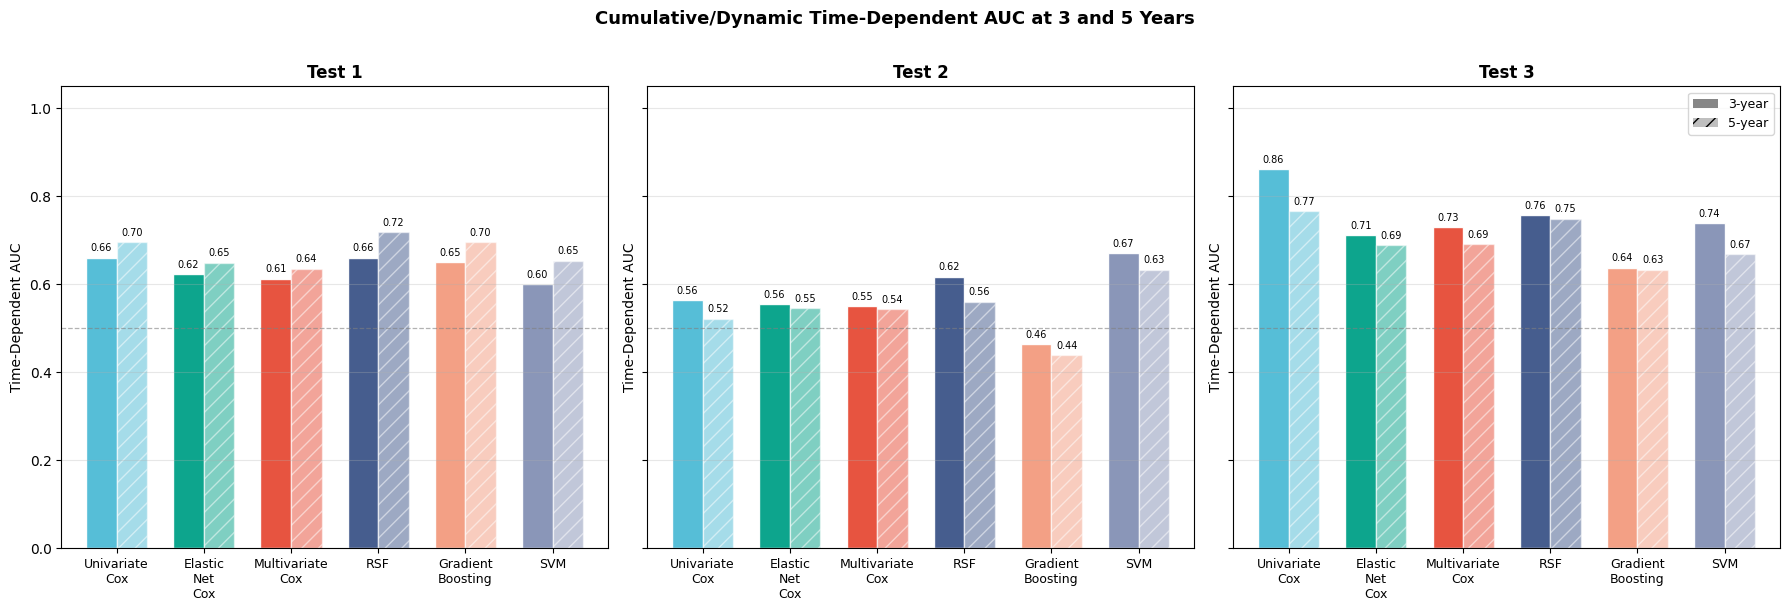

In [12]:
MODEL_ORDER  = ["Univariate Cox", "Elastic Net Cox", "Multivariate Cox",
                "RSF", "Gradient Boosting", "SVM"]
MODEL_COLORS = {
    "Univariate Cox":    "#4DBBD5",
    "Elastic Net Cox":   "#00A087",
    "Multivariate Cox":  "#E64B35",
    "RSF":               "#3C5488",
    "Gradient Boosting": "#F39B7F",
    "SVM":               "#8491B4",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
x     = np.arange(len(MODEL_ORDER))
width = 0.35

for ax, test_name in zip(axes, ["Test 1", "Test 2", "Test 3"]):
    subset   = auc_df[auc_df["Test Set"] == test_name].set_index("Model")
    aucs_3yr = [subset.loc[m, "AUC_3yr"] if m in subset.index else float("nan")
                for m in MODEL_ORDER]
    aucs_5yr = [subset.loc[m, "AUC_5yr"] if m in subset.index else float("nan")
                for m in MODEL_ORDER]
    colors   = [MODEL_COLORS[m] for m in MODEL_ORDER]

    bars3 = ax.bar(x - width / 2, aucs_3yr, width, color=colors,
                   alpha=0.95, edgecolor="white", label="3-year")
    bars5 = ax.bar(x + width / 2, aucs_5yr, width, color=colors,
                   alpha=0.50, edgecolor="white", hatch="//", label="5-year")

    for bars in (bars3, bars5):
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h) and h > 0:
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                        f"{h:.2f}", ha="center", va="bottom", fontsize=7)

    ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.9, alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(" ", "\n") for m in MODEL_ORDER], fontsize=9)
    ax.set_title(test_name, fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Time-Dependent AUC", fontsize=10)
    ax.grid(axis="y", alpha=0.3)

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor="grey", alpha=0.95, label="3-year"),
    Patch(facecolor="grey", alpha=0.50, hatch="//", label="5-year"),
]
axes[-1].legend(handles=legend_handles, loc="upper right", fontsize=9)

plt.suptitle("Cumulative/Dynamic Time-Dependent AUC at 3 and 5 Years",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../visuals/time_dependent_roc_auc.png", dpi=150, bbox_inches="tight")
print("Saved: time_dependent_roc_auc.png")
plt.show()

Saved: time_dependent_roc_heatmap.png


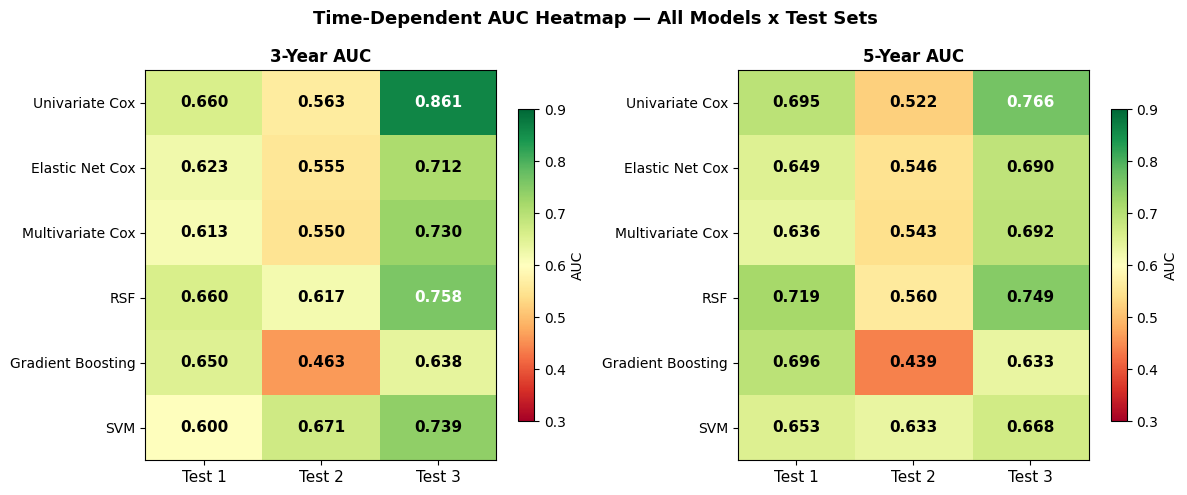

In [13]:
MODEL_ORDER = ["Univariate Cox", "Elastic Net Cox", "Multivariate Cox",
               "RSF", "Gradient Boosting", "SVM"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, time_col, label in zip(axes,
                                ["AUC_3yr", "AUC_5yr"],
                                ["3-Year AUC", "5-Year AUC"]):
    pivot = (auc_df.pivot(index="Model", columns="Test Set", values=time_col)
               .reindex(index=MODEL_ORDER))
    mat   = pivot.values.astype(float)

    im = ax.imshow(mat, cmap="RdYlGn", vmin=0.3, vmax=0.9, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_yticks(range(len(MODEL_ORDER)))
    ax.set_xticklabels(pivot.columns, fontsize=11)
    ax.set_yticklabels(MODEL_ORDER, fontsize=10)
    ax.set_title(label, fontsize=12, fontweight="bold")

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            if not np.isnan(v):
                text_color = "black" if 0.35 < v < 0.75 else "white"
                ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                        fontsize=11, fontweight="bold", color=text_color)

    plt.colorbar(im, ax=ax, shrink=0.8, label="AUC")

plt.suptitle("Time-Dependent AUC Heatmap — All Models x Test Sets",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../visuals/time_dependent_roc_heatmap.png", dpi=150, bbox_inches="tight")
print("Saved: time_dependent_roc_heatmap.png")
plt.show()

## Time-Dependent ROC Curves

IPCW cumulative/dynamic ROC at exactly 3 and 5 years. Layout: rows = test sets, columns = time points.

In [14]:
from sklearn.metrics import roc_curve, auc as sklearn_auc

# ── G_hat evaluator (reuses _t_km / _g_km computed in the setup cell) ────────
def g_hat_at(t, left_continuous=False):
    """
    Evaluate the training censoring KM at time t.
    left_continuous=True  → G_hat(t-), used for case IPCW weights
    left_continuous=False → G_hat(t),  used for control IPCW weights
    """
    side = "left" if left_continuous else "right"
    idx  = int(np.searchsorted(_t_km, t, side=side)) - 1
    return float(_g_km[idx]) if idx >= 0 else 1.0


def compute_ipcw_roc(y_prepared, risk_scores, t):
    """
    IPCW cumulative/dynamic ROC at time t.

    y_prepared : Surv.from_arrays output (fields "event", "time")
    risk_scores: 1-D array aligned with y_prepared
    t          : scalar evaluation time in days

    Returns (fpr, tpr, auc_val).
    """
    times  = y_prepared["time"].astype(float)
    events = y_prepared["event"].astype(bool)

    # Cumulative cases: event at or before t
    # Dynamic controls: last follow-up after t (event OR censored after t)
    case_mask = events & (times <= t)
    ctrl_mask = times > t

    if case_mask.sum() == 0 or ctrl_mask.sum() == 0:
        return np.array([0., 1.]), np.array([0., 1.]), 0.5

    include = case_mask | ctrl_mask
    y_bin   = case_mask[include].astype(int)
    r_inc   = risk_scores[include]
    t_inc   = times[include]

    # IPCW weights
    # Cases get 1/G_hat(T_i-); controls get 1/G_hat(t)
    g_ctrl = max(g_hat_at(t, left_continuous=False), 1e-10)
    w      = np.full(int(include.sum()), 1.0 / g_ctrl)

    is_case = y_bin == 1
    w[is_case] = [
        1.0 / max(g_hat_at(ti, left_continuous=True), 1e-10)
        for ti in t_inc[is_case]
    ]

    fpr, tpr, _ = roc_curve(y_bin, r_inc, sample_weight=w)
    return fpr, tpr, float(sklearn_auc(fpr, tpr))

Saved: time_dependent_roc_curves.png


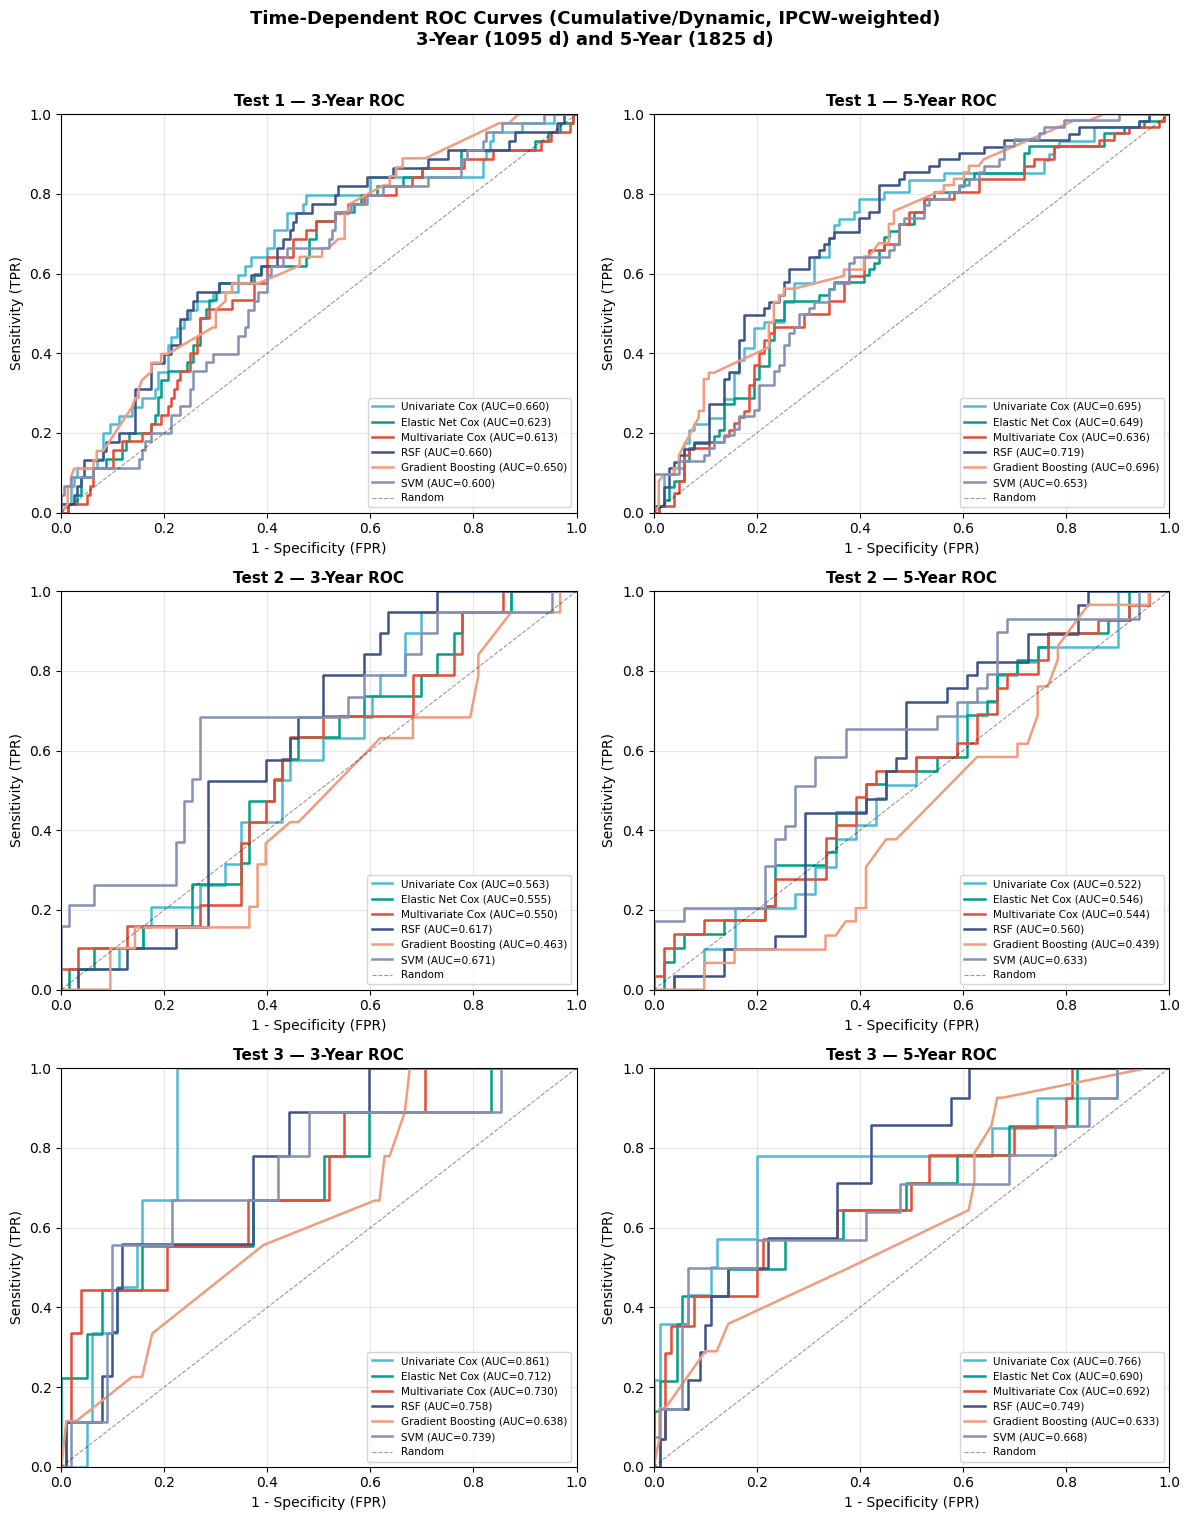

In [15]:
MODEL_ORDER  = ["Univariate Cox", "Elastic Net Cox", "Multivariate Cox",
                "RSF", "Gradient Boosting", "SVM"]
MODEL_COLORS = {
    "Univariate Cox":    "#4DBBD5",
    "Elastic Net Cox":   "#00A087",
    "Multivariate Cox":  "#E64B35",
    "RSF":               "#3C5488",
    "Gradient Boosting": "#F39B7F",
    "SVM":               "#8491B4",
}
TIME_POINTS = [(1095, "3-Year"), (1825, "5-Year")]

fig, axes = plt.subplots(3, 2, figsize=(12, 15))

for row_idx, (test_name, (y_test, split_key)) in enumerate(TEST_SETS.items()):
    for col_idx, (t_days, t_label) in enumerate(TIME_POINTS):
        ax = axes[row_idx, col_idx]

        for model_name in MODEL_ORDER:
            risk_raw = all_models[model_name][split_key]
            y_prep, r_prep = prepare_test_data(y_test, risk_raw, verbose=False)

            try:
                fpr, tpr, auc_val = compute_ipcw_roc(y_prep, r_prep, t_days)
                ax.plot(fpr, tpr,
                        label=f"{model_name} (AUC={auc_val:.3f})",
                        color=MODEL_COLORS[model_name],
                        linewidth=1.8)
            except Exception as e:
                print(f"  {test_name} | {t_label} | {model_name}: {e}")

        ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.4, label="Random")
        ax.set_xlabel("1 - Specificity (FPR)", fontsize=10)
        ax.set_ylabel("Sensitivity (TPR)", fontsize=10)
        ax.set_title(f"{test_name} — {t_label} ROC", fontsize=11, fontweight="bold")
        ax.legend(fontsize=7.5, loc="lower right")
        ax.grid(alpha=0.3)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

plt.suptitle("Time-Dependent ROC Curves (Cumulative/Dynamic, IPCW-weighted)\n"
             "3-Year (1095 d) and 5-Year (1825 d)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../visuals/time_dependent_roc_curves.png", dpi=150, bbox_inches="tight")
print("Saved: time_dependent_roc_curves.png")
plt.show()